In [1]:
import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn import preprocessing
from sklearn.metrics import confusion_matrix, recall_score, precision_score
from keras.models import Sequential,load_model
from keras.layers import Dense, Dropout, LSTM

# define path to save model
model_path = 'binary_model.h5'

In [2]:
train_df_26 = pd.read_csv(r'C:\Users\usman\Desktop\FYP\26th Mosfet\26th Mosfet Data.csv', na_values=['#NAME'])
train_df_17 = pd.read_csv(r'C:\Users\usman\Desktop\FYP\17th Mosfet\17th Mosfet Data.csv', na_values=['#NAME'])
train_df_17.columns = ['id','DC', 'VSD', 'R', 'Time(min)']
train_df_21 = pd.read_csv(r'C:\Users\usman\Desktop\FYP\21st Mosfet\21st Mosfet Data.csv', na_values=['#NAME'])
train_df_21.columns = ['id','DC', 'VSD', 'R', 'Time(min)']
train_df_26.columns = ['id','DC', 'VSD', 'R', 'Time(min)']
train_df_26.tail()

,id,DC,VSD,R,Time(min)
39218,26,0.241363,5.627031,23.313566,311.567953
39219,26,0.246448,5.622061,22.812395,311.584453
39220,26,0.246874,5.614268,22.741421,311.584563
39221,26,0.228635,5.623145,24.594428,311.601064
39222,26,0.235721,5.617070,23.829355,311.601174


In [3]:
train_df_17.tail()

,id,DC,VSD,R,Time(min)
3619,17,3.985421,8.361945,2.098134,34.946600
3620,17,3.943973,8.369344,2.122059,34.953283
3621,17,4.519818,8.243922,1.823950,34.975867
3622,17,4.126817,8.323828,2.017009,34.980567
3623,17,4.036007,8.348133,2.068414,34.987233


In [4]:
train_df_21.tail()

,id,DC,VSD,R,Time(min)
4103,21,0.256469,5.630791,5.630791,33.477183
4104,21,0.252205,5.622329,5.622329,33.483833
4105,21,0.259028,5.628970,5.628970,33.490517
4106,21,0.254764,5.632427,5.632427,33.497133
4107,21,0.269886,5.623438,5.623438,33.503783


In [5]:
train_df_26.describe()

,id,DC,VSD,R,Time(min)
count,39223.0,39223.000000,39223.000000,39223.000000,39223.000000
mean,26.0,1.130592,5.435877,16.237152,173.485335
std,0.0,1.164130,0.236155,11.636502,85.937940
min,26.0,0.171523,4.464277,0.777559,0.001115
25%,26.0,0.215415,5.137886,1.978551,108.051207
50%,26.0,0.241330,5.611592,23.281156,180.867825
75%,26.0,2.596712,5.621846,26.098137,246.234490
max,26.0,5.741397,5.657910,32.825710,311.601174


In [6]:
rul = pd.DataFrame(train_df_26.groupby('id')['Time(min)'].max()).reset_index()
rul.columns = ['id', 'max']
train_df_26 = train_df_26.merge(rul, on=['id'], how='left')
train_df_26['RUL'] = train_df_26['max'] - train_df_26['Time(min)']
train_df_26.drop('max', axis=1, inplace=True)

# Generate label columns for training data
# we will only make use of "label1" for binary classification, while trying to answer the question: is a specific Mosfet going to fail within w1 cycles?
w1 = 30
w0 = 15
train_df_26['label1'] = np.where(train_df_26['RUL'] <= w1, 1, 0 )
train_df_26['label2'] = train_df_26['label1']
train_df_26.loc[train_df_26['RUL'] <= w0, 'label2'] = 2

# MinMax normalization (from 0 to 1)
train_df_26['Time(min)_norm'] = train_df_26['Time(min)']
cols_normalize = train_df_26.columns.difference(['id','Time(min)','RUL','label1','label2'])
min_max_scaler = preprocessing.MinMaxScaler()
norm_train_df_26 = pd.DataFrame(min_max_scaler.fit_transform(train_df_26[cols_normalize]), 
                             columns=cols_normalize, 
                             index=train_df_26.index)
join_df = train_df_26[train_df_26.columns.difference(cols_normalize)].join(norm_train_df_26)
train_df_26 = join_df.reindex(columns = train_df_26.columns)
train_df_26.tail()

,id,DC,VSD,R,Time(min),RUL,label1,label2,Time(min)_norm
39218,26,0.012539,0.974130,0.703192,311.567953,0.033222,1,2,0.999893
39219,26,0.013452,0.969966,0.687554,311.584453,0.016722,1,2,0.999946
39220,26,0.013528,0.963437,0.685339,311.584563,0.016611,1,2,0.999947
39221,26,0.010254,0.970874,0.743159,311.601064,0.000111,1,2,1.000000
39222,26,0.011526,0.965785,0.719286,311.601174,0.000000,1,2,1.000000


In [8]:
rul = pd.DataFrame(train_df_17.groupby('id')['Time(min)'].max()).reset_index()
rul.columns = ['id', 'max']
train_df_17 = train_df_17.merge(rul, on=['id'], how='left')
train_df_17['RUL'] = train_df_17['max'] - train_df_17['Time(min)']
train_df_17.drop('max', axis=1, inplace=True)

# Generate label columns for training data
# we will only make use of "label1" for binary classification, while trying to answer the question: is a specific Mosfet going to fail within w1 cycles?
w1 = 30
w0 = 15
train_df_17['label1'] = np.where(train_df_17['RUL'] <= w1, 1, 0 )
train_df_17['label2'] = train_df_17['label1']
train_df_17.loc[train_df_17['RUL'] <= w0, 'label2'] = 2

# MinMax normalization (from 0 to 1)
train_df_17['Time(min)_norm'] = train_df_17['Time(min)']
cols_normalize = train_df_17.columns.difference(['id','Time(min)','RUL','label1','label2'])
min_max_scaler = preprocessing.MinMaxScaler()
norm_train_df_17 = pd.DataFrame(min_max_scaler.fit_transform(train_df_17[cols_normalize]), 
                             columns=cols_normalize, 
                             index=train_df_17.index)
join_df = train_df_17[train_df_17.columns.difference(cols_normalize)].join(norm_train_df_17)
train_df_17 = join_df.reindex(columns = train_df_17.columns)
train_df_17.tail()

,id,DC,VSD,R,Time(min),RUL,label1,label2,Time(min)_norm
3619,17,0.025816,0.984141,0.961571,34.946600,0.040633,1,2,0.998839
3620,17,0.014559,0.993210,0.982488,34.953283,0.033950,1,2,0.999030
3621,17,0.170952,0.839463,0.721868,34.975867,0.011367,1,2,0.999675
3622,17,0.064217,0.937415,0.890649,34.980567,0.006667,1,2,0.999809
3623,17,0.039554,0.967209,0.935589,34.987233,0.000000,1,2,1.000000


In [9]:
rul = pd.DataFrame(train_df_21.groupby('id')['Time(min)'].max()).reset_index()
rul.columns = ['id', 'max']
train_df_21 = train_df_21.merge(rul, on=['id'], how='left')
train_df_21['RUL'] = train_df_21['max'] - train_df_21['Time(min)']
train_df_21.drop('max', axis=1, inplace=True)

# Generate label columns for training data
# we will only make use of "label1" for binary classification, while trying to answer the question: is a specific Mosfet going to fail within w1 cycles?
w1 = 30
w0 = 15
train_df_21['label1'] = np.where(train_df_21['RUL'] <= w1, 1, 0 )
train_df_21['label2'] = train_df_21['label1']
train_df_21.loc[train_df_21['RUL'] <= w0, 'label2'] = 2

# MinMax normalization (from 0 to 1)
train_df_21['Time(min)_norm'] = train_df_21['Time(min)']
cols_normalize = train_df_21.columns.difference(['id','Time(min)','RUL','label1','label2'])
min_max_scaler = preprocessing.MinMaxScaler()
norm_train_df_21 = pd.DataFrame(min_max_scaler.fit_transform(train_df_21[cols_normalize]), 
                             columns=cols_normalize, 
                             index=train_df_21.index)
join_df = train_df_21[train_df_21.columns.difference(cols_normalize)].join(norm_train_df_21)
train_df_21 = join_df.reindex(columns = train_df_21.columns)
train_df_21.tail()

,id,DC,VSD,R,Time(min),RUL,label1,label2,Time(min)_norm
4103,21,0.007940,0.985265,0.985265,33.477183,0.026600,1,2,0.999206
4104,21,0.007165,0.978061,0.978061,33.483833,0.019950,1,2,0.999405
4105,21,0.008406,0.983714,0.983714,33.490517,0.013267,1,2,0.999604
4106,21,0.007630,0.986657,0.986657,33.497133,0.006650,1,2,0.999802
4107,21,0.010380,0.979005,0.979005,33.503783,0.000000,1,2,1.000000


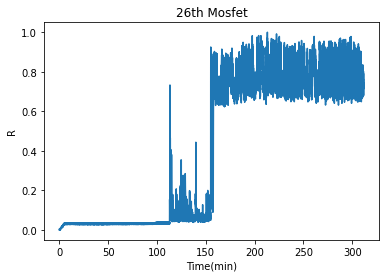

In [10]:
train_df_26.set_index('Time(min)', inplace=True)
train_df_26['R'].plot(ylabel = 'R', title='26th Mosfet')
plt.savefig("R26_norm")

<AxesSubplot:title={'center':'26th Mosfet'}, xlabel='Time(min)', ylabel='R100ma'>

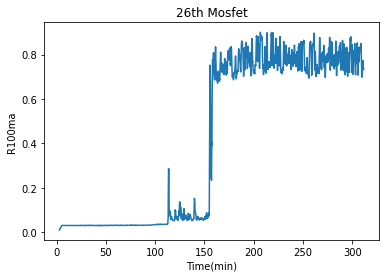

In [11]:
train_df_26["R"].rolling(100).mean().plot(ylabel = 'R100ma', title='26th Mosfet')

In [12]:
train_df_17.set_index('Time(min)', inplace=True)
train_df_21.set_index('Time(min)', inplace=True)

<AxesSubplot:title={'center':'17th MOSFET'}, xlabel='Time(min)', ylabel='R'>

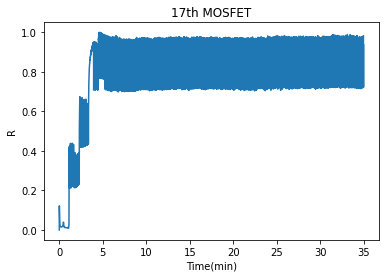

In [13]:
train_df_17['R'].plot(ylabel='R', title='17th MOSFET')

In [14]:
train_df_17.tail()

,id,DC,VSD,R,RUL,label1,label2,Time(min)_norm
Time(min),,,,,,,,
34.946600,17,0.025816,0.984141,0.961571,0.040633,1,2,0.998839
34.953283,17,0.014559,0.993210,0.982488,0.033950,1,2,0.999030
34.975867,17,0.170952,0.839463,0.721868,0.011367,1,2,0.999675
34.980567,17,0.064217,0.937415,0.890649,0.006667,1,2,0.999809
34.987233,17,0.039554,0.967209,0.935589,0.000000,1,2,1.000000


<AxesSubplot:title={'center':'17th MOSFET'}, xlabel='Time(min)', ylabel='R20ma'>

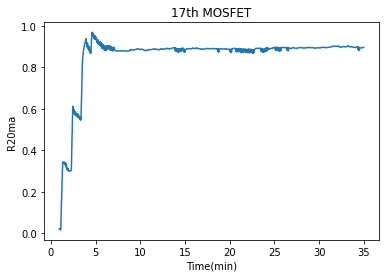

In [15]:
train_df_17["R"].rolling(20).mean().plot(ylabel = 'R20ma', title='17th MOSFET')

In [16]:
train_df_26['R100ma'] = train_df_26["R"].rolling(100).mean()

In [17]:
train_df_17['R20ma'] = train_df_17["R"].rolling(20).mean()
train_df_21['R20ma'] = train_df_21["R"].rolling(20).mean()

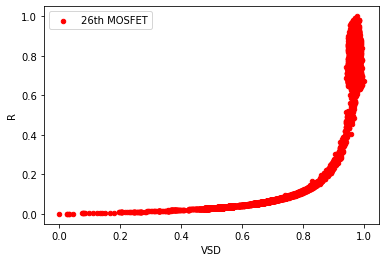

In [18]:
# a scatter plot
train_df_26.plot(kind='scatter',x='VSD',y='R',color='red',label="26th MOSFET")
plt.show()

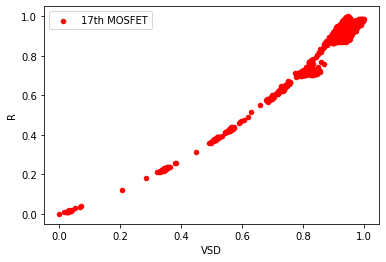

In [19]:
# a scatter plot
train_df_17.plot(kind='scatter',x='VSD',y='R',color='red', label="17th MOSFET")
plt.show()

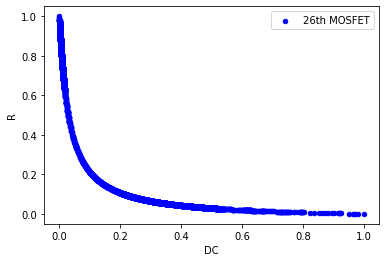

In [20]:
# a scatter plot
train_df_26.plot(kind='scatter',x='DC',y='R',color='blue', label="26th MOSFET")
plt.show()

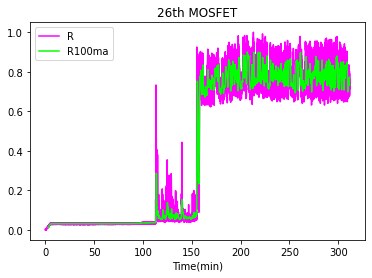

In [21]:
ax = plt.gca()

train_df_26.plot(kind='line',y='R', color='Fuchsia', ax=ax, use_index=True, label="R", title="26th MOSFET")
train_df_26.plot(kind='line',y='R100ma', color='Lime' ,ax=ax, use_index=True, label="R100ma")

plt.show()

In [22]:
train_df_26['VSD100ma'] = train_df_26["VSD"].rolling(100).mean()
train_df_26['DC100ma'] = train_df_26["DC"].rolling(100).mean()

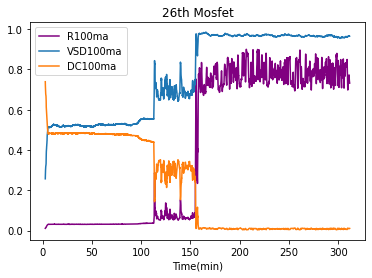

In [23]:
ax = plt.gca()

train_df_26.plot(kind='line',y='R100ma', color='purple', ax=ax, use_index=True, title='26th Mosfet')
train_df_26.plot(kind='line',y='VSD100ma',ax=ax, use_index=True)
train_df_26.plot(kind='line',y='DC100ma',ax=ax, use_index=True)

plt.show()

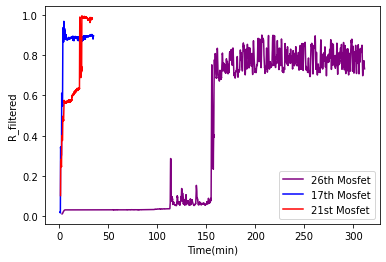

In [24]:
ax = plt.gca()

train_df_26.plot(kind='line',y='R100ma', color='purple', ax=ax, use_index=True, ylabel = 'R_filtered', label = '26th Mosfet')
train_df_17.plot(kind='line',y='R20ma', color='blue', ax=ax, use_index=True, label = '17th Mosfet')
train_df_21.plot(kind='line',y='R20ma', color='red', ax=ax, use_index=True, label = '21st Mosfet')

plt.show()